<a href="https://colab.research.google.com/github/ahcamachod/2257-fundamentos-ia-explorando-algoritmos-y-enfoques-de-ml/blob/proyecto-final/fundamentos_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase 1: Aprendizaje supervisado**

## Clasificación con el dataset Iris

En esta sección entrenamos modelos que aprenden a asignar una clase a cada ejemplo. Usaremos el dataset Iris, donde cada flor se describe con medidas de sépalos y pétalos, y el objetivo es predecir la especie.


In [86]:
# Objetivo: entrenar un Árbol de decisión para clasificar flores Iris.
# El modelo recibe medidas de la flor y predice una de tres especies.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargamos un dataset clásico incluido en scikit-learn.
# X contiene las variables de entrada: largo/ancho de sépalos y pétalos.
# y contiene la clase correcta de cada flor: setosa, versicolor o virginica.
iris = load_iris()
X = iris.data
y = iris.target

# Separamos datos para entrenar y datos para evaluar.
# test_size=0.3 reserva el 30% de los ejemplos para prueba.
# stratify=y mantiene una proporción similar de especies en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamos el Árbol. random_state hace que el resultado sea reproducible.
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluamos con datos que el modelo no vio durante el entrenamiento.
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")


Exactitud del modelo: 93.33%


In [87]:
# Objetivo: comparar dos algoritmos de clasificación en el mismo dataset.
# Árbol de decisión: divide los datos mediante reglas.
# KNN: clasifica según los vecinos más cercanos.
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd

# Convertimos Iris a DataFrame para ver con claridad columnas y etiqueta.
dataset = load_iris()
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# KNN depende de distancias, por eso normalizamos las variables numéricas.
# StandardScaler deja cada variable con media cercana a 0 y desviación estándar 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['species']))

# Dividimos los datos de forma estratificada para conservar el balance de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['species'], test_size=0.3, random_state=42, stratify=df['species']
)

# Modelo 1: Árbol de decisión.
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_accuracy = accuracy_score(y_test, tree_model.predict(X_test))
print(f"Exactitud del modelo de Árbol de Decisión: {tree_accuracy * 100:.2f}%")

# Modelo 2: K vecinos más cercanos.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_accuracy = accuracy_score(y_test, knn_model.predict(X_test))
print(f"Exactitud del modelo KNN: {knn_accuracy * 100:.2f}%")


Exactitud del modelo de Árbol de Decisión: 93.33%
Exactitud del modelo KNN: 91.11%


## Regresión lineal

La regresión se usa cuando queremos predecir un valor numérico continuo. En el ejemplo se simula el precio de inmuebles a partir de su tamaño para observar cómo una recta puede aproximar la relación entre ambas variables.


Coeficiente angular (b1): 19.43
Intercepto (b0): 514.29

Métricas de Evaluación:
R² en datos de prueba: 0.94
Error Medio Absoluto (MAE): 7.39
Raíz del Error Cuadrático Medio (RMSE): 9.34

Promedio de los puntajes de la validación cruzada: 0.95


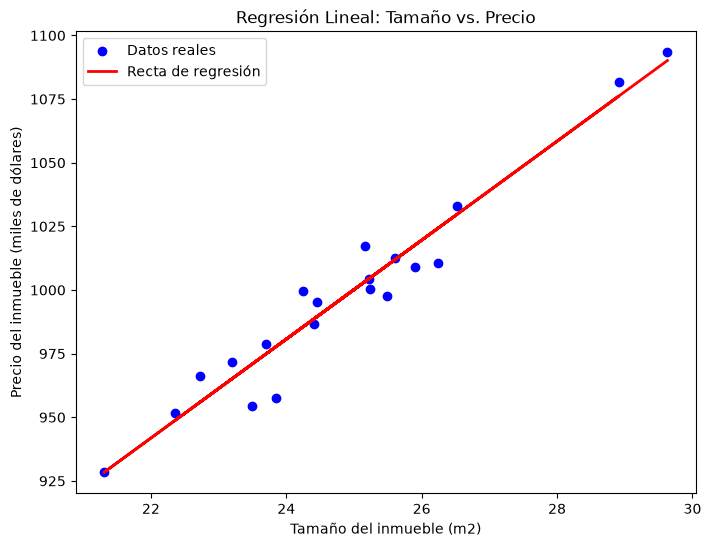

In [88]:
# Objetivo: entrenar una regresión lineal para predecir un valor continuo.
# En este ejemplo simulamos tamaños de inmuebles y sus precios.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fijamos la semilla para que los datos simulados sean iguales en cada ejecución.
np.random.seed(42)
X = 2.5 * np.random.randn(100, 1) + 25  # Tamaño del inmueble en m2.
y = 500 + (X * 20) + np.random.randn(100, 1) * 10  # Precio en miles de dólares.

# En scikit-learn, X representa las variables de entrada y y la salida esperada.
features = X
labels = y

# Reservamos 20% de los datos para medir el desempeño con ejemplos no vistos.
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# El modelo aprende los coeficientes de la ecuación: y = b0 + b1 * X.
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coeficiente angular (b1): {model.coef_[0][0]:.2f}")
print(f"Intercepto (b0): {model.intercept_[0]:.2f}")

# Generamos predicciones y calculamos métricas de error.
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)  # Qué proporción de la variación explica el modelo.
mae = mean_absolute_error(y_test, y_pred)  # Error promedio en unidades del precio.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Penaliza más los errores grandes.

print("\nMétricas de Evaluación:")
print(f"R² en datos de prueba: {r2:.2f}")
print(f"Error Medio Absoluto (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Validación cruzada: repite entrenamiento/evaluación en 5 particiones.
cv_scores = cross_val_score(model, features, labels.ravel(), cv=5, scoring='r2')
print(f"\nPromedio de los puntajes de la validación cruzada: {cv_scores.mean():.2f}")

# Gráfico: puntos reales frente a la recta aprendida por el modelo.
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Recta de regresión')
plt.xlabel("Tamaño del inmueble (m2)")
plt.ylabel("Precio del inmueble (miles de dólares)")
plt.title("Regresión Lineal: Tamaño vs. Precio")
plt.legend()
plt.show()


# **Clase 2: Modelos de clasificación y regresión**

En esta clase se practican flujos completos de aprendizaje automático: cargar datos, preparar variables, entrenar modelos, evaluar resultados y visualizar errores o aciertos.


In [89]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Cargamos datos reales de viviendas de California.
# Cada fila describe características de una zona y PRICE es el valor medio de vivienda.
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Mostramos las primeras filas para inspeccionar columnas y escala de valores.
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Error Cuadrático Medio (MSE): 0.53
Coeficiente de Determinación (R²): 0.60


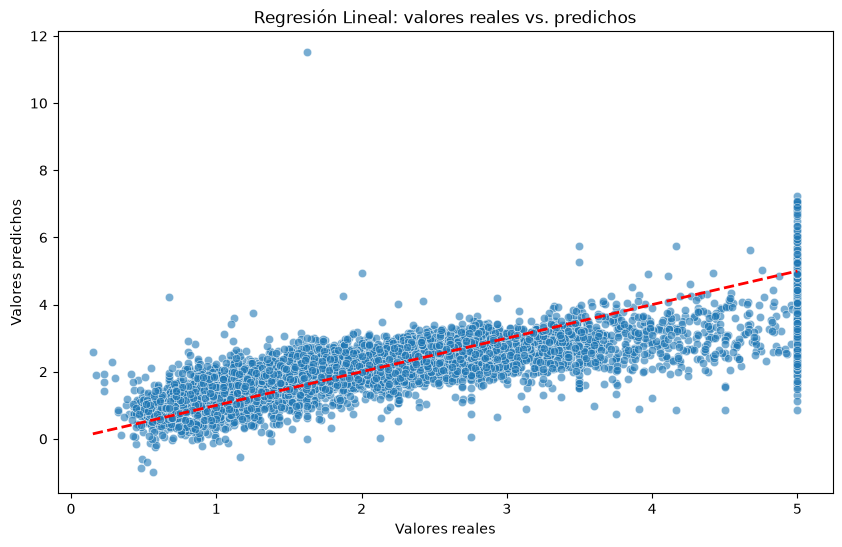

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Cargamos el dataset y construimos un DataFrame para trabajar de forma legible.
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# X contiene las variables predictoras; y contiene el precio a predecir.
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Entrenamos una regresión lineal como modelo base.
model = LinearRegression()
model.fit(X_train, y_train)

# Predecimos y evaluamos.
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Si el modelo fuera perfecto, los puntos caerían sobre la línea roja diagonal.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal: valores reales vs. predichos")
plt.show()


In [91]:
from sklearn.datasets import load_diabetes

# Cargar los datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Ver las primeras 5 filas de los datos
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Exactitud del modelo: 80.45%


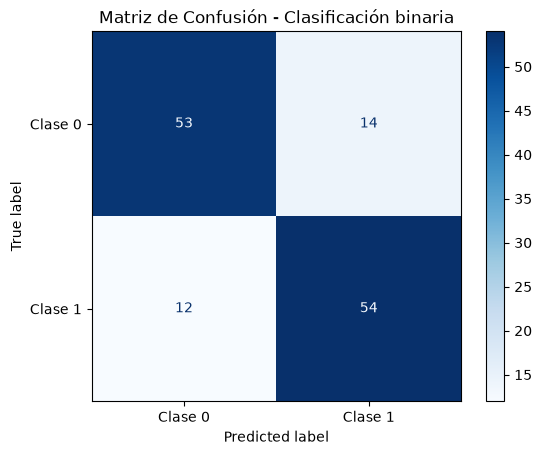

In [92]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Usamos el dataset Diabetes como ejemplo de clasificación binaria.
# La variable original es continua; la convertimos en 0/1 usando la mediana.
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['OUTCOME'] = diabetes.target
df['OUTCOME'] = (df['OUTCOME'] > df['OUTCOME'].median()).astype(int)

# 0 significa valor igual/inferior a la mediana; 1 significa superior a la mediana.
X = df.drop('OUTCOME', axis=1)
y = df['OUTCOME']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# max_iter evita que el entrenamiento se corte antes de converger.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")

# La matriz de confusión muestra aciertos y errores por clase.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Clasificación binaria")
plt.show()


In [93]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# GridSearchCV prueba varias combinaciones de hiperparámetros y elige la mejor.
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Hiperparámetros del Árbol:
# max_depth limita la profundidad, min_samples_split controla cuándo dividir nodos
# y min_samples_leaf evita hojas con muy pocos ejemplos.
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor MSE promedio en validación: {-grid_search.best_score_:.2f}")


Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor MSE promedio en validación: 0.42


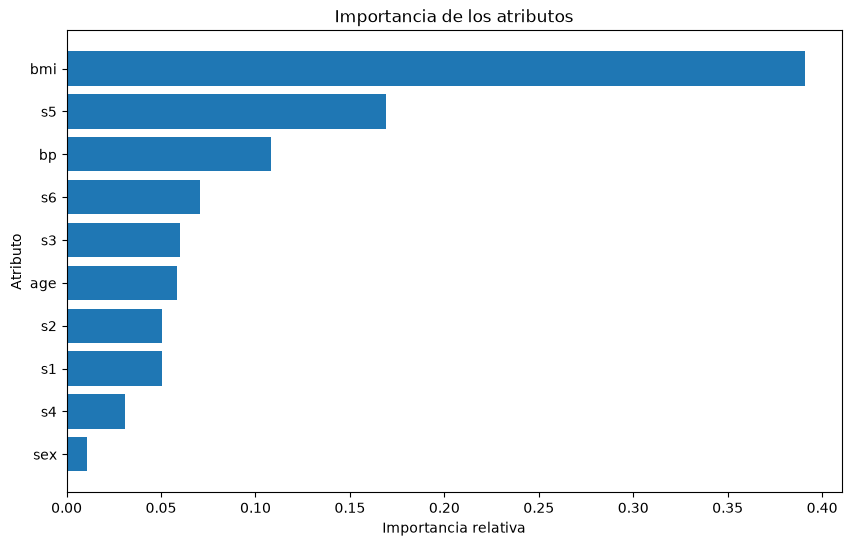

In [94]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Random Forest permite estimar qué variables aportan más a las predicciones.
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# feature_importances_ devuelve un peso relativo para cada variable.
importances = model.feature_importances_
importance_df = pd.DataFrame({'atributo': feature_names, 'importancia': importances})
importance_df = importance_df.sort_values('importancia')

plt.figure(figsize=(10, 6))
plt.barh(importance_df['atributo'], importance_df['importancia'])
plt.title("Importancia de los atributos")
plt.xlabel("Importancia relativa")
plt.ylabel("Atributo")
plt.show()


Random Forest - MSE: 0.29, R²: 0.78
Gradient Boosting - MSE: 0.24, R²: 0.82


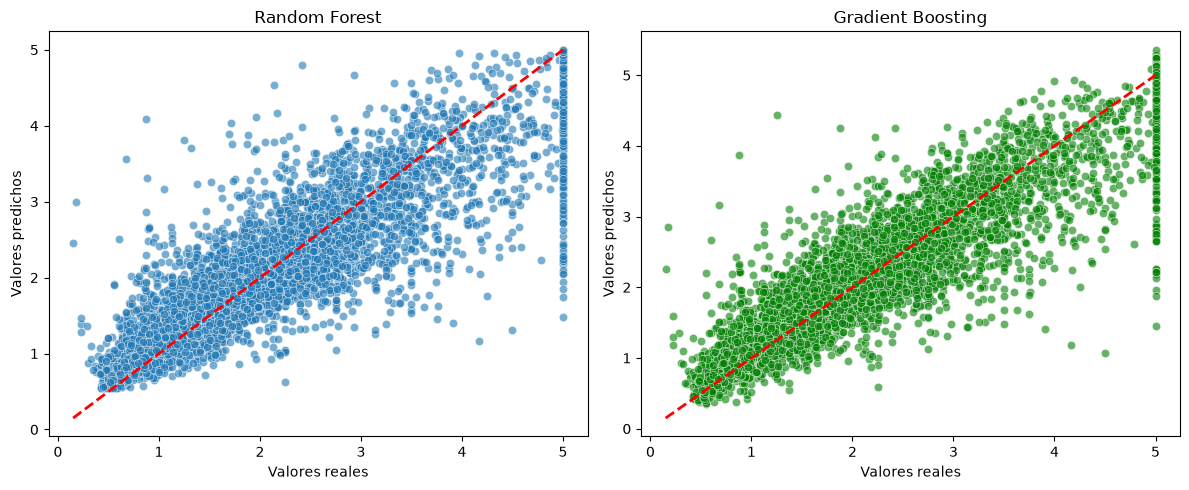

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Comparamos dos modelos ensemble para regresión.
# Random Forest promedia muchos Árboles; Gradient Boosting construye Árboles secuenciales
# que intentan corregir errores del modelo anterior.
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")
print(f"Gradient Boosting - MSE: {mse_gb:.2f}, R²: {r2_gb:.2f}")

# La línea roja representa predicción perfecta.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Random Forest")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.6, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Gradient Boosting")

plt.tight_layout()
plt.show()


# **Clase 3: Aprendizaje no supervisado**

## Clustering

En el aprendizaje no supervisado no entregamos etiquetas al modelo. El algoritmo intenta encontrar estructura en los datos, por ejemplo grupos de ejemplos parecidos entre sí.


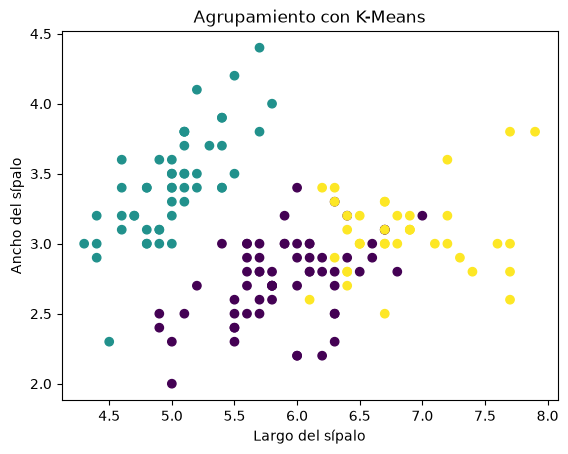

In [96]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-Means agrupa ejemplos buscando centroides, es decir, puntos centrales de cada grupo.
iris = load_iris()
X = iris.data

# Pedimos 3 grupos porque sabemos que Iris tiene 3 especies, aunque el modelo no usa esas etiquetas.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Visualizamos dos variables del dataset para observar los grupos encontrados.
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title("Agrupamiento con K-Means")
plt.xlabel("Largo del sípalo")
plt.ylabel("Ancho del sípalo")
plt.show()


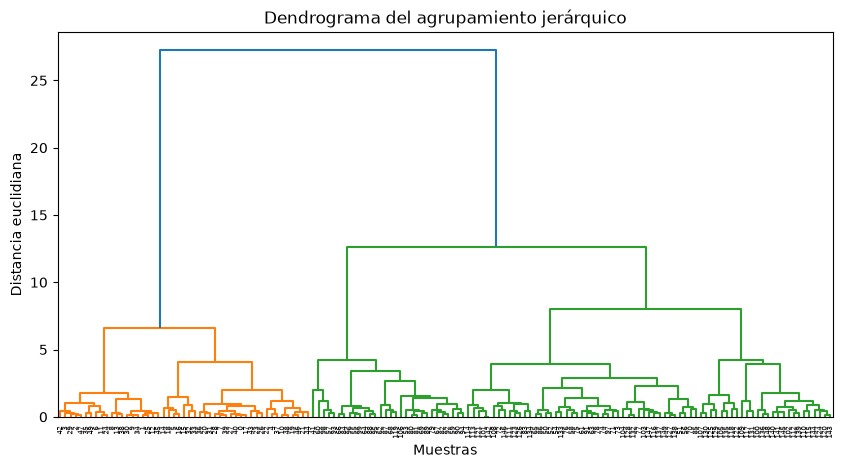

In [97]:
from sklearn.datasets import load_iris
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# El clustering jerárquico construye una estructura de grupos dentro de grupos.
iris = load_iris()
X = iris.data

# Normalizamos para que ninguna variable domine por tener una escala mayor.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# El dendrograma muestra a qué distancia se van uniendo los ejemplos o grupos.
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrograma del agrupamiento jerárquico")
plt.xlabel("Muestras")
plt.ylabel("Distancia euclidiana")
plt.show()


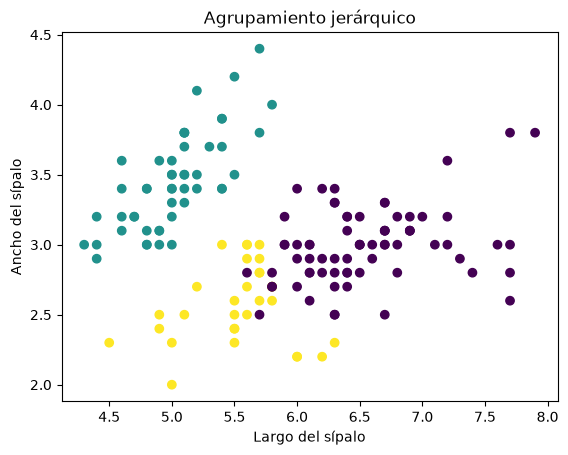

In [98]:
from sklearn.cluster import AgglomerativeClustering

# Convertimos el dendrograma en 3 clusters finales.
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(X_scaled)

plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title("Agrupamiento jerárquico")
plt.xlabel("Largo del sípalo")
plt.ylabel("Ancho del sípalo")
plt.show()


## Reducción de dimensionalidad con PCA

PCA transforma muchas variables originales en pocas componentes principales. La idea es conservar la mayor parte de la información posible y facilitar la visualización o el análisis.


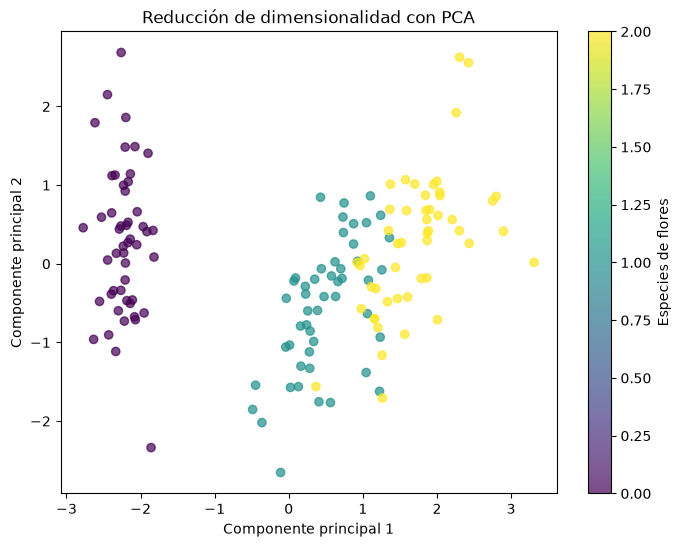

In [99]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Iris tiene 4 variables. PCA las resume en 2 componentes para poder graficarlas.
iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Reducción de dimensionalidad con PCA")
plt.colorbar(label="Especies de flores")
plt.show()


In [100]:
# explained_variance_ratio_ indica cuánta información conserva cada componente.
varianza = pca.explained_variance_ratio_
print(varianza)
print(f"Varianza acumulada: {varianza.sum():.2f}")


[0.72962445 0.22850762]
Varianza acumulada: 0.96


# **Clase 4: Procesamiento de imágenes y modelos preentrenados**

En esta sección trabajamos con `poseidon.png`. Primero observamos una imagen como matriz de píxeles y luego vemos dos ideas clave de visión por computadora: una arquitectura CNN básica y el uso de MobileNetV2 preentrenado.


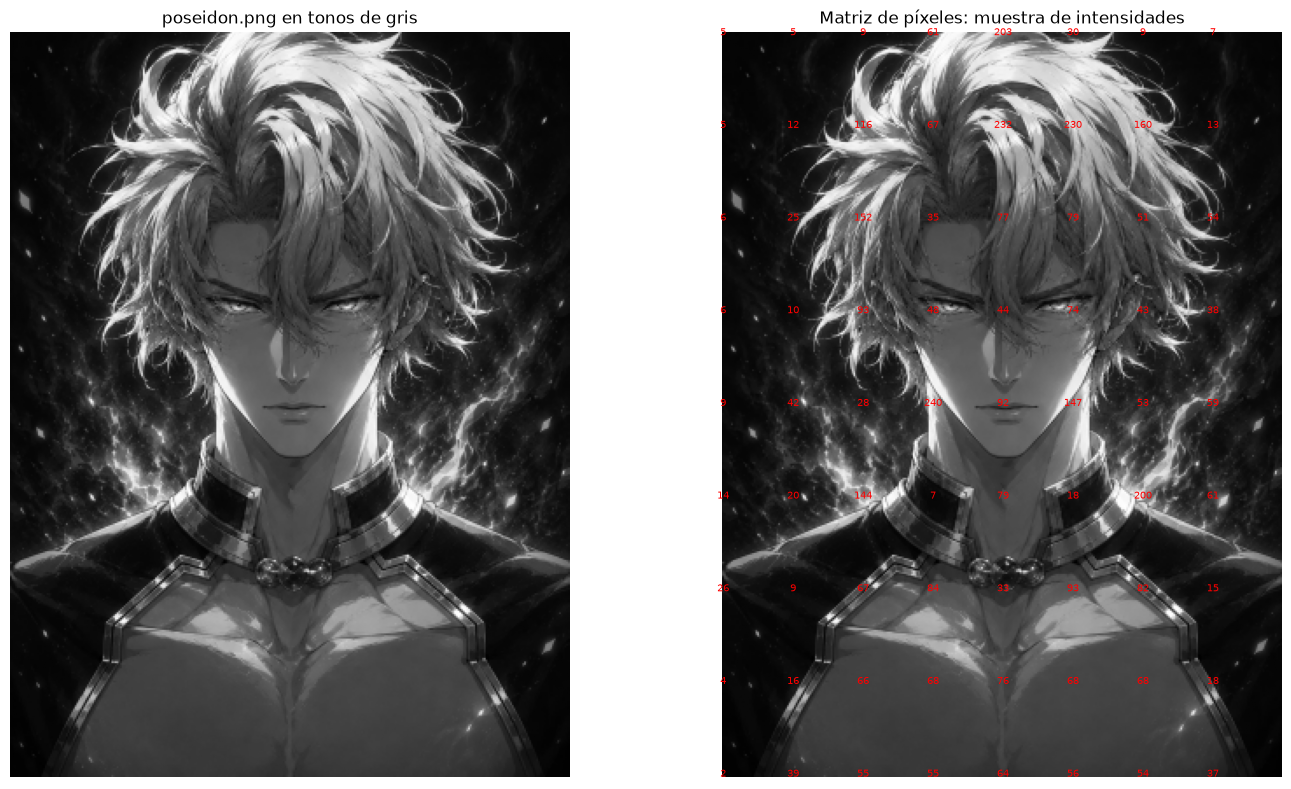

In [101]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Usamos poseidon.png como imagen principal del ejercicio.
# Si el notebook se ejecuta en Colab y el archivo no está disponible,
# se abrirá un cuadro de subida para cargar la imagen manualmente.
image_path = Path("poseidon.png")
if not image_path.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        image_path = Path("poseidon.png") if Path("poseidon.png").exists() else Path(next(iter(uploaded)))
    except ModuleNotFoundError as exc:
        raise FileNotFoundError("No se encontró poseidon.png en la carpeta del notebook.") from exc

# OpenCV carga la imagen como matriz. En escala de grises cada píxel vale de 0 a 255:
# 0 representa negro, 255 representa blanco y los valores intermedios son grises.
imagen = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if imagen is None:
    raise ValueError("OpenCV no pudo leer la imagen. Verifica que poseidon.png sea un archivo válido.")

# Para que los números de píxeles se vean claros, reducimos solo la visualización.
# La imagen original queda intacta en disco.
max_display_width = 320
scale = min(1, max_display_width / imagen.shape[1])
display_size = (int(imagen.shape[1] * scale), int(imagen.shape[0] * scale))
imagen_display = cv2.resize(imagen, display_size, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(imagen_display, cmap="gray")
plt.title("poseidon.png en tonos de gris")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_display, cmap="gray")
plt.title("Matriz de píxeles: muestra de intensidades")
step_y = max(20, imagen_display.shape[0] // 8)
step_x = max(20, imagen_display.shape[1] // 8)
for i in range(0, imagen_display.shape[0], step_y):
    for j in range(0, imagen_display.shape[1], step_x):
        plt.text(j, i, str(int(imagen_display[i, j])), color="red", fontsize=7, ha='center', va='center')
plt.axis("off")
plt.tight_layout()
plt.show()


In [102]:
import os

# En Windows, esta variable evita inicializaciones lentas o conflictos de oneDNN.
# Debe definirse antes de importar TensorFlow/Keras.
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Esta CNN es un ejemplo educativo de arquitectura, no está entrenada todavía.
# Flujo: convoluciones detectan patrones, pooling reduce tamaño, Dense clasifica.
modelo = Sequential([
    Input(shape=(64, 64, 3)),              # Imágenes RGB de 64x64 píxeles.
    Conv2D(32, (3, 3), activation='relu'), # Filtros que aprenden bordes/texturas.
    MaxPooling2D(pool_size=(2, 2)),         # Reduce dimensiones y conserva señales fuertes.
    Flatten(),                             # Convierte mapas 2D en un vector.
    Dense(128, activation='relu'),          # Combina las características aprendidas.
    Dense(3, activation='softmax')          # Probabilidades para 3 clases.
])
modelo.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,936,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937,667 (15.02 MB)

 Trainable params: 3,937,667 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

In [103]:
import os

# En Windows, esta variable evita inicializaciones lentas o conflictos de oneDNN.
# Debe definirse antes de importar TensorFlow/Keras.
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np
import cv2
from pathlib import Path

# MobileNetV2 ya fue entrenado con ImageNet, por eso puede reconocer objetos comunes.
# Aquí usamos poseidon.png como entrada del modelo.
imagen_path = Path("poseidon.png")
if not imagen_path.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        imagen_path = Path("poseidon.png") if Path("poseidon.png").exists() else Path(next(iter(uploaded)))
    except ModuleNotFoundError as exc:
        raise FileNotFoundError("No se encontró poseidon.png en la carpeta del notebook.") from exc

imagen = cv2.imread(str(imagen_path))
if imagen is None:
    raise ValueError("OpenCV no pudo leer la imagen. Verifica que poseidon.png sea un archivo válido.")

# OpenCV usa BGR; los modelos de Keras esperan RGB.
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

modelo = MobileNetV2(weights="imagenet")

# MobileNetV2 espera imágenes de 224x224 y preprocesadas con preprocess_input.
imagen_redimensionada = cv2.resize(imagen_rgb, (224, 224))
imagen_array = np.expand_dims(imagen_redimensionada, axis=0)
imagen_array = preprocess_input(imagen_array)

predicciones = modelo.predict(imagen_array)
etiquetas = decode_predictions(predicciones, top=3)[0]

print("Top 3 predicciones para poseidon.png:")
for _, nombre, probabilidad in etiquetas:
    print(f"- {nombre}: {probabilidad * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Top 3 predicciones para poseidon.png:
- wig: 40.12%
- mask: 4.39%
- neck_brace: 2.15%
